In [ ]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import re
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F


con = duckdb.connect('../capillary.db')

df = con.execute(""" 
                 SELECT id, value, delimit_value, delimit_value2,analysis, protein_value, label
                 FROM protein_data 
                 AND label != 4
                 AND label != 3
                 AND value IS NOT NULL
                 AND delimit_value IS NOT NULL
                 AND delimit_value2 IS NOT NULL
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


def extract_relevant_values(analysis_list, value_list, relevant):
    # Skapa dict från analysis -> value för denna rad
    mapping = dict(zip(analysis_list, value_list))
    
    # Plocka ut relevanta värden i fast ordning
    return [mapping.get(code, np.nan) for code in relevant]

def extract_fractions(delimit_list):
    fractions = []
    for item in delimit_list:
        match = re.search(r'(\d+\.?\d*)\s*%', str(item))
        if match:
            fractions.append(float(match.group(1)))
    return fractions

def clean_value(val):
    if val is None or val == '' or val == 'NA' or val == 'NEG':
        return np.nan
    try:
        return float(str(val).replace('<', '').replace('>', '').strip())
    except:
        return np.nan

def clean_protein_values(val_list):
    return [clean_value(v) for v in val_list]

#value
df = df[ df['value'].apply(len) == 301 ] #vaska de rader där value inte har rätt längd (typ bara en korrupt rad)
df['value'] = df['value'].apply(lambda x: x[:300])

#delimit_value
df['delimit_value'] = df['delimit_value'].apply(extract_fractions)
df = df[ df['delimit_value'].apply(len) == 6]

#delimit_value2
df = df[ df['delimit_value2'].apply(len) == 15]

#hämta ut protein-value
relevant_anlysis = ['0054','0055','0056','0058','0062','0064','0065','0066']
df['protein_value'] = df.apply(
    lambda row: extract_relevant_values(
        row['analysis'], 
        row['protein_value'], 
        relevant_anlysis
    ), 
    axis=1
)
df['protein_value'] = df['protein_value'].apply(clean_protein_values)

X_curve     = np.array(df['value'].tolist(),         dtype=np.float32)  # (n, 300)
X_fractions = np.array(df['delimit_value'].tolist(),  dtype=np.float32)  # (n, 6)
X_delimit2  = np.array(df['delimit_value2'].tolist(), dtype=np.float32)  # (n, 15)
X_protein   = np.array(df['protein_value'].tolist(),  dtype=np.float32)  # (n, 8)

protein_missing = np.isnan(X_protein).astype(np.float32)  # (n, 8)

X = np.concatenate([X_curve, X_fractions, X_delimit2,X_protein], axis=1)  # (n, 329)
y = np.array(df['label'].values, dtype=np.int64)


print(X.shape) 
print(y.shape)  

# Kolla att det inte finns NaN eller inf
print(f"NaN: {np.isnan(X).sum()}")
print(f"Inf: {np.isinf(X).sum()}")

# Kolla klassbalansen
unique, counts = np.unique(y, return_counts=True)
for val, count in zip(unique, counts):
    print(f"Label {val}: {count} ({count/len(y)*100:.1f}%)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(145024, 329)
(145024,)
NaN: 26800
Inf: 0
Label 0: 108926 (75.1%)
Label 1: 25690 (17.7%)
Label 2: 10408 (7.2%)


In [17]:

ids = df['id'].values

# Först: låt 15% vara test-set
ids_temp, ids_test, X_temp, X_test, y_temp, y_test = train_test_split(
    ids, X, y, test_size=0.15, random_state=42, stratify=y
)

# Sedan: dela resten i träning/validering (0.1765 ≈ 15% av totalen)
ids_train, ids_val, X_train, X_val, y_train, y_val = train_test_split(
    ids_temp, X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)
# Efter din train_test_split, lägg till detta block:
PROTEIN_COLS = slice(321, 329)  # kolumn 321–328 = X_protein
protein_medians = np.nanmedian(X_train[:, PROTEIN_COLS], axis=0)  # (8,)

train_missing = np.isnan(X_train[:, PROTEIN_COLS]).astype(np.float32)  # (n_train, 8)
val_missing   = np.isnan(X_val[:,   PROTEIN_COLS]).astype(np.float32)
test_missing  = np.isnan(X_test[:,  PROTEIN_COLS]).astype(np.float32)

# Applicera på alla tre splits
for split in [X_train, X_val, X_test]:
    for i, col in enumerate(range(321, 329)):
        mask = np.isnan(split[:, col])
        split[mask, col] = protein_medians[i]

# Verifiera att inga NaN kvarstår
print(f"NaN efter imputation: {np.isnan(X_train).sum()}")

X_train = np.concatenate([X_train, train_missing], axis=1)  # (n_train, 337)
X_val   = np.concatenate([X_val,   val_missing],   axis=1)
X_test  = np.concatenate([X_test,  test_missing],  axis=1)

# Normalisera bara de extra features, inte kurvan
scaler = StandardScaler()
X_train[:, 300:] = scaler.fit_transform(X_train[:, 300:])
X_val[:, 300:]   = scaler.transform(X_val[:, 300:])
X_test[:, 300:]  = scaler.transform(X_test[:, 300:])

X_train = torch.tensor(X_train,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.long)

X_val = torch.tensor(X_val,dtype=torch.float32)
y_val = torch.tensor(y_val,dtype=torch.long)

X_test = torch.tensor(X_test,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.long)


ids_train_tensor = torch.tensor(ids_train)
ids_val_tensor = torch.tensor(ids_val)
ids_test_tensor = torch.tensor(ids_test)


print(f"Träning:    {len(X_train):>6} ({len(X_train)/len(y):.0%})")
print(f"Validering: {len(X_val):>6} ({len(X_val)/len(y):.0%})")
print(f"Test:       {len(X_test):>6} ({len(X_test)/len(y):.0%})")

print(torch.isnan(X_train).sum())
print(torch.isinf(X_train).sum())


NaN efter imputation: 0
Träning:    101512 (70%)
Validering:  21758 (15%)
Test:        21754 (15%)
tensor(0)
tensor(0)


In [18]:
batch_sz = 256  # ökad från 64

train_dataloader = DataLoader(TensorDataset(X_train, y_train, ids_train_tensor), batch_size=batch_sz, shuffle=True)
val_dataloader   = DataLoader(TensorDataset(X_val,   y_val, ids_val_tensor),   batch_size=batch_sz)
test_dataloader = DataLoader(TensorDataset(X_test, y_test, ids_test_tensor), batch_size=batch_sz)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.narrow = nn.Conv1d(in_ch, out_ch, kernel_size=3,  padding=1)
        self.medium = nn.Conv1d(in_ch, out_ch, kernel_size=7,  padding=3)
        self.wide   = nn.Conv1d(in_ch, out_ch, kernel_size=15, padding=7)
        self.bn     = nn.BatchNorm1d(out_ch * 3)

    def forward(self, x):
        return F.relu(self.bn(torch.cat([
            self.narrow(x),
            self.medium(x),
            self.wide(x)
        ], dim=1)))


class SEResBlock(nn.Module):
    def __init__(self, channels, kernel_size=5, reduction=4):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=kernel_size//2)
        self.bn1   = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=kernel_size//2)
        self.bn2   = nn.BatchNorm1d(channels)
        self.se    = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        residual = x
        out   = F.relu(self.bn1(self.conv1(x)))
        out   = self.bn2(self.conv2(out))
        scale = self.se(out).unsqueeze(-1)
        return F.relu(out * scale + residual)


class CNN1D_Fast(nn.Module):
    def __init__(self, extra_features=37):
        super().__init__()

        # Multi-scale ingång — tre parallella conv, billigt eftersom in_ch=1
        self.narrow = nn.Conv1d(1, 16, kernel_size=3,  padding=1)
        self.medium = nn.Conv1d(1, 16, kernel_size=7,  padding=3)
        self.wide   = nn.Conv1d(1, 16, kernel_size=15, padding=7)
        # → 48 kanaler ut

        # Enkel sekventiell CNN utan ResBlock eller BatchNorm
        self.conv = nn.Sequential(
            nn.ReLU(),
            nn.MaxPool1d(2),                         # 300 -> 150
            nn.Conv1d(48, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),                         # 150 -> 75
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),                         # 75 -> 37
        )

        # Enkel attention — bara ett linjärt lager
        self.attention = nn.Linear(37, 37)

        self.fc = nn.Sequential(
            nn.Linear(64 + extra_features, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        curve = x[:, :300].unsqueeze(1)
        extra = x[:, 300:]

        # Multi-scale
        out = torch.cat([
            self.narrow(curve),
            self.medium(curve),
            self.wide(curve)
        ], dim=1)                                    # (batch, 48, 300)

        out = self.conv(out)                         # (batch, 64, 37)

        # Attention över positioner
        attn = torch.softmax(self.attention(
            out.mean(dim=1)                          # (batch, 37)
        ), dim=-1).unsqueeze(1)                      # (batch, 1, 37)
        context = (out * attn).sum(dim=-1)           # (batch, 64)

        combined = torch.cat([context, extra], dim=1)
        return self.fc(combined)

    def get_attention_weights(self, x):
        self.eval()
        with torch.no_grad():
            curve = x[:, :300].unsqueeze(1)
            out = torch.cat([
                self.narrow(curve),
                self.medium(curve),
                self.wide(curve)
            ], dim=1)
            out = self.conv(out)
            attn = torch.softmax(self.attention(
                out.mean(dim=1)
            ), dim=-1)
        return attn

def train(train_dataloader, model, loss_fn, optimizer):
    model.train()
    for X, y,_ in train_dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

def validate(val_dataloader, model, loss_fn):
    size = len(val_dataloader.dataset)
    num_batches = len(val_dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y,_ in val_dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    return (100*correct, test_loss)

def test(test_dataloader, model, loss_fn):
    size = len(test_dataloader.dataset)
    num_batches = len(test_dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    return (100*correct, test_loss)

model = CNN1D_Fast(extra_features=37).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)  # L2 regularisering
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.9)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Antal parametrar: {total_params:,}")

Using mps device
CNN1D_Fast(
  (narrow): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (medium): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
  (wide): Conv1d(1, 16, kernel_size=(15,), stride=(1,), padding=(7,))
  (conv): Sequential(
    (0): ReLU()
    (1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): Conv1d(48, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (3): ReLU()
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (attention): Linear(in_features=37, out_features=37, bias=True)
  (fc): Sequential(
    (0): Linear(in_features=101, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)
Antal parametrar: 42,944


In [19]:
epochs = 200
best_loss = float('inf')
patience = 4
min_delta = 1e-3          # förbättring måste vara > 0.001 för att räknas
epochs_without_improvement = 0
accuracies = []
validation_losses = []

for t in range(epochs):
    train(train_dataloader, model, loss_fn, optimizer)
    accuracy, avg_loss = validate(val_dataloader, model, loss_fn)
    accuracies.append(accuracy)
    validation_losses.append(avg_loss)  # var ett bug här också — du sparade accuracy
    scheduler.step(avg_loss)
    print(f"Epoch {t}, accuracy: {accuracy:.4f}, loss: {avg_loss:.6f}, "
          f"lr: {optimizer.param_groups[0]['lr']:.2e}")

    if avg_loss < best_loss - min_delta:
        best_loss = avg_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "attention.pth")  # spara här!
        print(f"  → Ny bästa modell sparad (loss: {best_loss:.6f})")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping efter {t} epoker")
            break

print("Done! Laddar bästa modellen...")
model.load_state_dict(torch.load("attention.pth", weights_only=True))

Epoch 0, accuracy: 91.6904, loss: 0.055700, lr: 1.00e-03
  → Ny bästa modell sparad (loss: 0.055700)
Epoch 1, accuracy: 91.7226, loss: 0.053739, lr: 1.00e-03
  → Ny bästa modell sparad (loss: 0.053739)
Epoch 2, accuracy: 91.7180, loss: 0.053703, lr: 1.00e-03
Epoch 3, accuracy: 91.7134, loss: 0.053773, lr: 1.00e-03
Epoch 4, accuracy: 91.7318, loss: 0.053400, lr: 1.00e-03
Epoch 5, accuracy: 91.7364, loss: 0.051492, lr: 1.00e-03
  → Ny bästa modell sparad (loss: 0.051492)
Epoch 6, accuracy: 91.7502, loss: 0.051030, lr: 1.00e-03
Epoch 7, accuracy: 91.7410, loss: 0.051570, lr: 1.00e-03
Epoch 8, accuracy: 91.7364, loss: 0.055149, lr: 1.00e-03
Epoch 9, accuracy: 91.7456, loss: 0.049535, lr: 1.00e-03
  → Ny bästa modell sparad (loss: 0.049535)
Epoch 10, accuracy: 91.7272, loss: 0.049742, lr: 1.00e-03
Epoch 11, accuracy: 91.7364, loss: 0.059211, lr: 1.00e-03
Epoch 12, accuracy: 91.7639, loss: 0.051523, lr: 1.00e-03
Epoch 13, accuracy: 91.7869, loss: 0.049793, lr: 1.00e-03
Early stopping efter 1

<All keys matched successfully>

In [20]:
from sklearn.metrics import confusion_matrix

#model.load_state_dict(torch.load("attention.pth", weights_only=True))

# Samla alla prediktioner
def evaluate_model(model, dataloader, loss_fn):
    model.eval()
    
    all_preds = []
    all_labels = []
    all_ids = []
    
    total_loss = 0
    num_batches = len(dataloader)

    with torch.no_grad():
        for X, y, ids in dataloader:
            X, y = X.to(device), y.to(device)
            
            pred = model(X)
            loss = loss_fn(pred, y)
            
            total_loss += loss.item()
            
            all_preds.extend(pred.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_ids.extend(ids.numpy())

    # Konvertera till numpy
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_ids = np.array(all_ids)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Felklassificeringar
    errors = all_preds != all_labels
    
    fn_ids = all_ids[(all_labels == 1) & (all_preds == 0)]
    fp_ids = all_ids[(all_labels == 0) & (all_preds == 1)]

    accuracy = (all_preds == all_labels).mean() * 100
    avg_loss = total_loss / num_batches

    return {
        "accuracy": accuracy,
        "loss": avg_loss,
        "confusion_matrix": cm,
        "fn_ids": fn_ids,
        "fp_ids": fp_ids,
        "all_preds": all_preds,
        "all_labels": all_labels,
        "all_ids": all_ids
    }

results = evaluate_model(model, test_dataloader, loss_fn)

print("Accuracy:", results["accuracy"])
print("Loss:", results["loss"])
print("Confusion matrix:\n", results["confusion_matrix"])

print(f"False negatives: {len(results['fn_ids'])}")
print(f"False positives: {len(results['fp_ids'])}")

con = duckdb.connect('../capillary.db')

df_fn = pd.DataFrame({
    'id': results["fn_ids"],
    'type': 'FN'
})

df_fp = pd.DataFrame({
    'id': results["fp_ids"],
    'type': 'FP'
})

df_all = pd.concat([df_fn, df_fp])

con.execute("DELETE FROM misspredictions")
con.execute("INSERT INTO misspredictions SELECT * FROM df_all")

con.close()

Accuracy: 91.80380619656155
Loss: 0.047762759720139644
Confusion matrix:
 [[16328    11     0]
 [  211  3643     0]
 [ 1199   362     0]]
False negatives: 211
False positives: 11


IOException: IO Error: Could not set lock on file "/Users/assarleideman/exjobb/capillary.db": Conflicting lock is held in /opt/homebrew/Cellar/duckdb/1.5.0/bin/duckdb (PID 65456) by user assarleideman. See also https://duckdb.org/docs/stable/connect/concurrency

In [ ]:
results = evaluate_model(model, train_dataloader, loss_fn)
print("Accuracy:", results["accuracy"])
print("Loss:", results["loss"])
print("Confusion matrix:\n", results["confusion_matrix"])

print(f"False negatives: {len(results['fn_ids'])}")
print(f"False positives: {len(results['fp_ids'])}")

Accuracy: 94.45299126779486
Loss: 0.19075589781817967
Confusion matrix:
 [[71019    25     0]
 [   45 16163     0]
 [ 3422  1628     0]]
False negatives: 45
False positives: 25


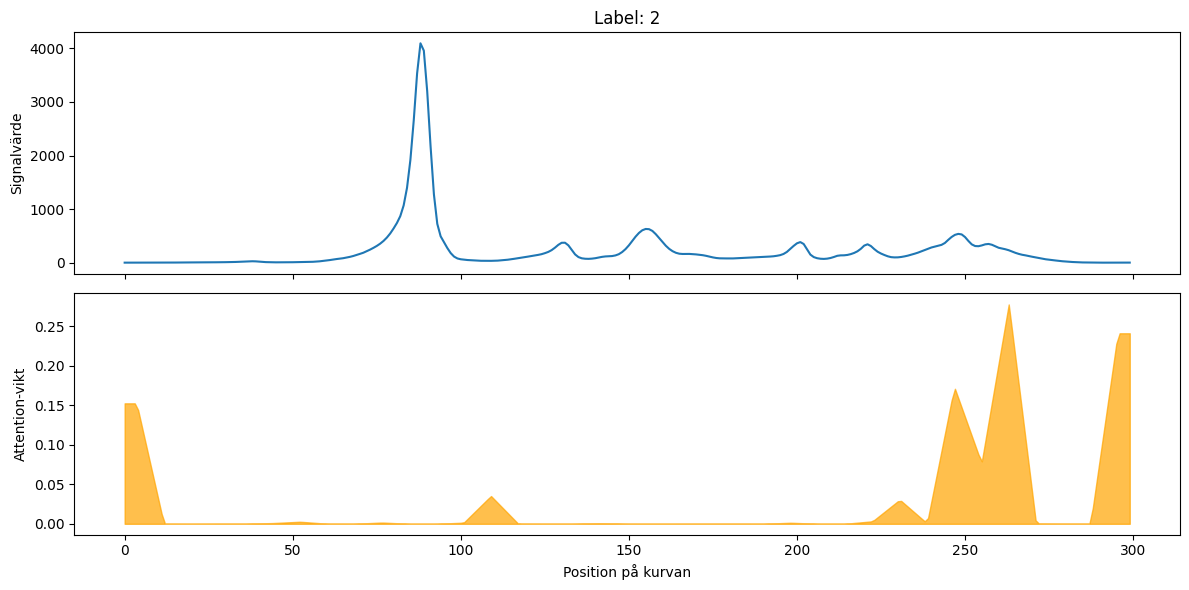

In [ ]:
import matplotlib.pyplot as plt

# Ta ett exempel ur test-set
sample = X_test[0:1].to(device) # (1, 337)
attn = model.get_attention_weights(sample)  # (1, 37)

sample = sample.cpu()
# Interpolera attention tillbaka till 300 punkter för visualisering
attn = attn.cpu()

attn_upsampled = F.interpolate(
    attn.unsqueeze(1), size=300, mode='linear', align_corners=False
).squeeze().numpy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(sample[0, :300].numpy())
ax1.set_ylabel("Signalvärde")
ax1.set_title(f"Label: {y_test[0].item()}")
ax2.fill_between(range(300), attn_upsampled, alpha=0.7, color='orange')
ax2.set_ylabel("Attention-vikt")
ax2.set_xlabel("Position på kurvan")
plt.tight_layout()
plt.show()

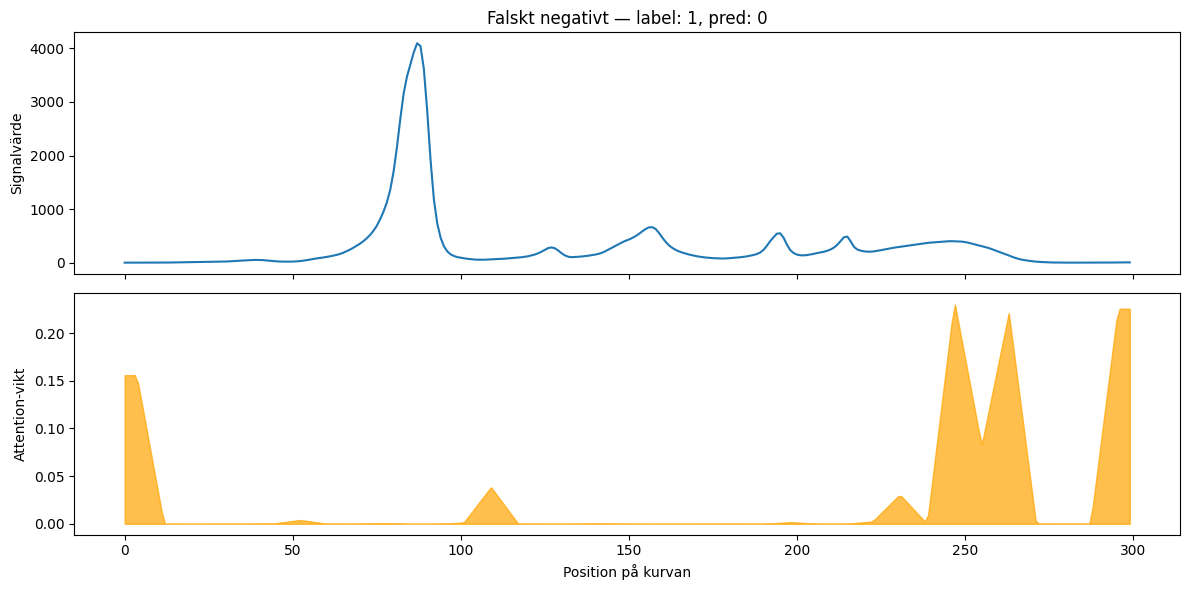

In [ ]:
# Hämta ett FN-fall
fn_idx = np.where((results["all_labels"] == 1) & 
                  (results["all_preds"] == 0))[0][0]

sample_fn = X_test[fn_idx:fn_idx+1].to(device)
attn_fn = model.get_attention_weights(sample_fn).cpu()

attn_up = F.interpolate(
    attn_fn.unsqueeze(1), size=300, mode='linear', align_corners=False
).squeeze().numpy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(sample_fn[0, :300].cpu().numpy())
ax1.set_ylabel("Signalvärde")
ax1.set_title(f"Falskt negativt — label: 1, pred: 0")
ax2.fill_between(range(300), attn_up, alpha=0.7, color='orange')
ax2.set_ylabel("Attention-vikt")
ax2.set_xlabel("Position på kurvan")
plt.tight_layout()
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    sample_fn = X_test[fn_idx:fn_idx+1].to(device)
    logits = model(sample_fn)
    probs = torch.softmax(logits, dim=1)
    print(f"P(negativ): {probs[0,0]:.3f}")
    print(f"P(positiv): {probs[0,1]:.3f}")

P(negativ): 0.935
P(positiv): 0.065


In [ ]:
con = duckdb.connect('../capillary.db')
df_analysis = con.execute("""
    SELECT
        p.id, 
        m.type,
        p.interpretation,
        p.m_component,
        p.age,
        p.gender,
    FROM misspredictions m
    JOIN protein_data p ON m.id = p.id
    ORDER BY m.type
""").df()
con.close()

df_fn = df_analysis[df_analysis['type'] == 'FN']
df_fp = df_analysis[df_analysis['type'] == 'FP']

print("=== FALSE NEGATIVES ===")
print(f"Totalt: {len(df_fn)}")
print(df_fn[['interpretation','id']].to_string(index=False))

print("\n=== FALSE POSITIVES ===")
print(f"Totalt: {len(df_fp)}")
print(df_fp[['interpretation','id']].to_string(index=False))

=== FALSE NEGATIVES ===
Totalt: 7
                                                                                                                                                                                                                                                                         interpretation    id
                              Patienten med känd IgM kappa M-komponent. Idag: Tecken på lätt inflammation.  Patientens IgM kappa M-komponent har idag en halt på 9,71 g/L.  Bakgrundsimmunglobulin-nivån är ej sänkt.  Förhöjda halter av protein HC, kappa- och lambdakedjor i urinen. 10576
Inga tecken på inflammation.  Patientens IgA kappa M-komponent har idag en halt på 5,43 g/L. Bakgrundsimmunglobulin-nivån är ej sänkt. Urin: Bence-Jones proteinuri av typ kappa. Utsöndring av 30 g kappakedjor/mol kreatinin. Även förhöjda halter av flera andra proteiner i urinen. 39783
                         Förhöjd halt av haptoglobin som enda tecken på inflammation.  Patientens IgA lambda